# COSC 426 / 526 - Project
## Title: Analyzing Patterns and Predicting Severity of Traffic Accidents in Tennessee: The Impact of Weather and Temporal Factors
#### By: Nagendra Upadhyay
---

This notebook analyzes how weather conditions (e.g., rain, snow) and time-related factors (hour, day of week) jointly influence the number and severity of accidents in Tennessee using the US Accidents dataset (2016–2023).

### **Dataset:** US Accidents (2016 - 2023)
- Link: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents?resource=download


### **Research Question:**
How do weather conditions and temporal factors (time of day, day of week) jointly impact the frequency and severity of accidents in the State of Tennessee?

### Data Collection & understanding

As the original dataset is very big with many entries points, I extracted the data to be only for the state of "TN". By running the code below I was able to make a subset of the main dataset. The code below is blocked as the data has been extracted and we do not need to rerun the code below. The project uses the 'TN_accidents.csv' as the main dataset.

In [816]:
#import pandas as pd

# Load the dataset (adjust path if needed)
#file_path = 'US_Accidents_March23.csv'
#df = pd.read_csv(file_path)

# Filter for Tennessee (TN) only
#tn_df = df[df['State'] == 'TN']

# Save to a new CSV file
#tn_df.to_csv('TN_accidents.csv', index=False)

# Calculate statistics
#total_accidents = len(df)
#tn_accidents = len(tn_df)
#percentage = (tn_accidents / total_accidents) * 100

# Print results
#print(f"Total accidents in dataset: {total_accidents:,}")
#print(f"Accidents in Tennessee (TN): {tn_accidents:,}")
#print(f"Percentage of total accidents: {percentage:.2f}%")

# Show first few rows of the filtered data
#print("\nPreview of Tennessee accidents data:")
#tn_df.head()

print(f"Total accidents in dataset: 7,728,394")
print(f"Accidents in Tennessee (TN): 167,388")
print(f"Percentage of total accidents: 2.17%")

Total accidents in dataset: 7,728,394
Accidents in Tennessee (TN): 167,388
Percentage of total accidents: 2.17%


**Load Libraries and Filtered Dataset**

In [829]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('TN_accidents.csv')

# Display basic info
print("Dataset Shape:", df.shape)

Dataset Shape: (167388, 46)


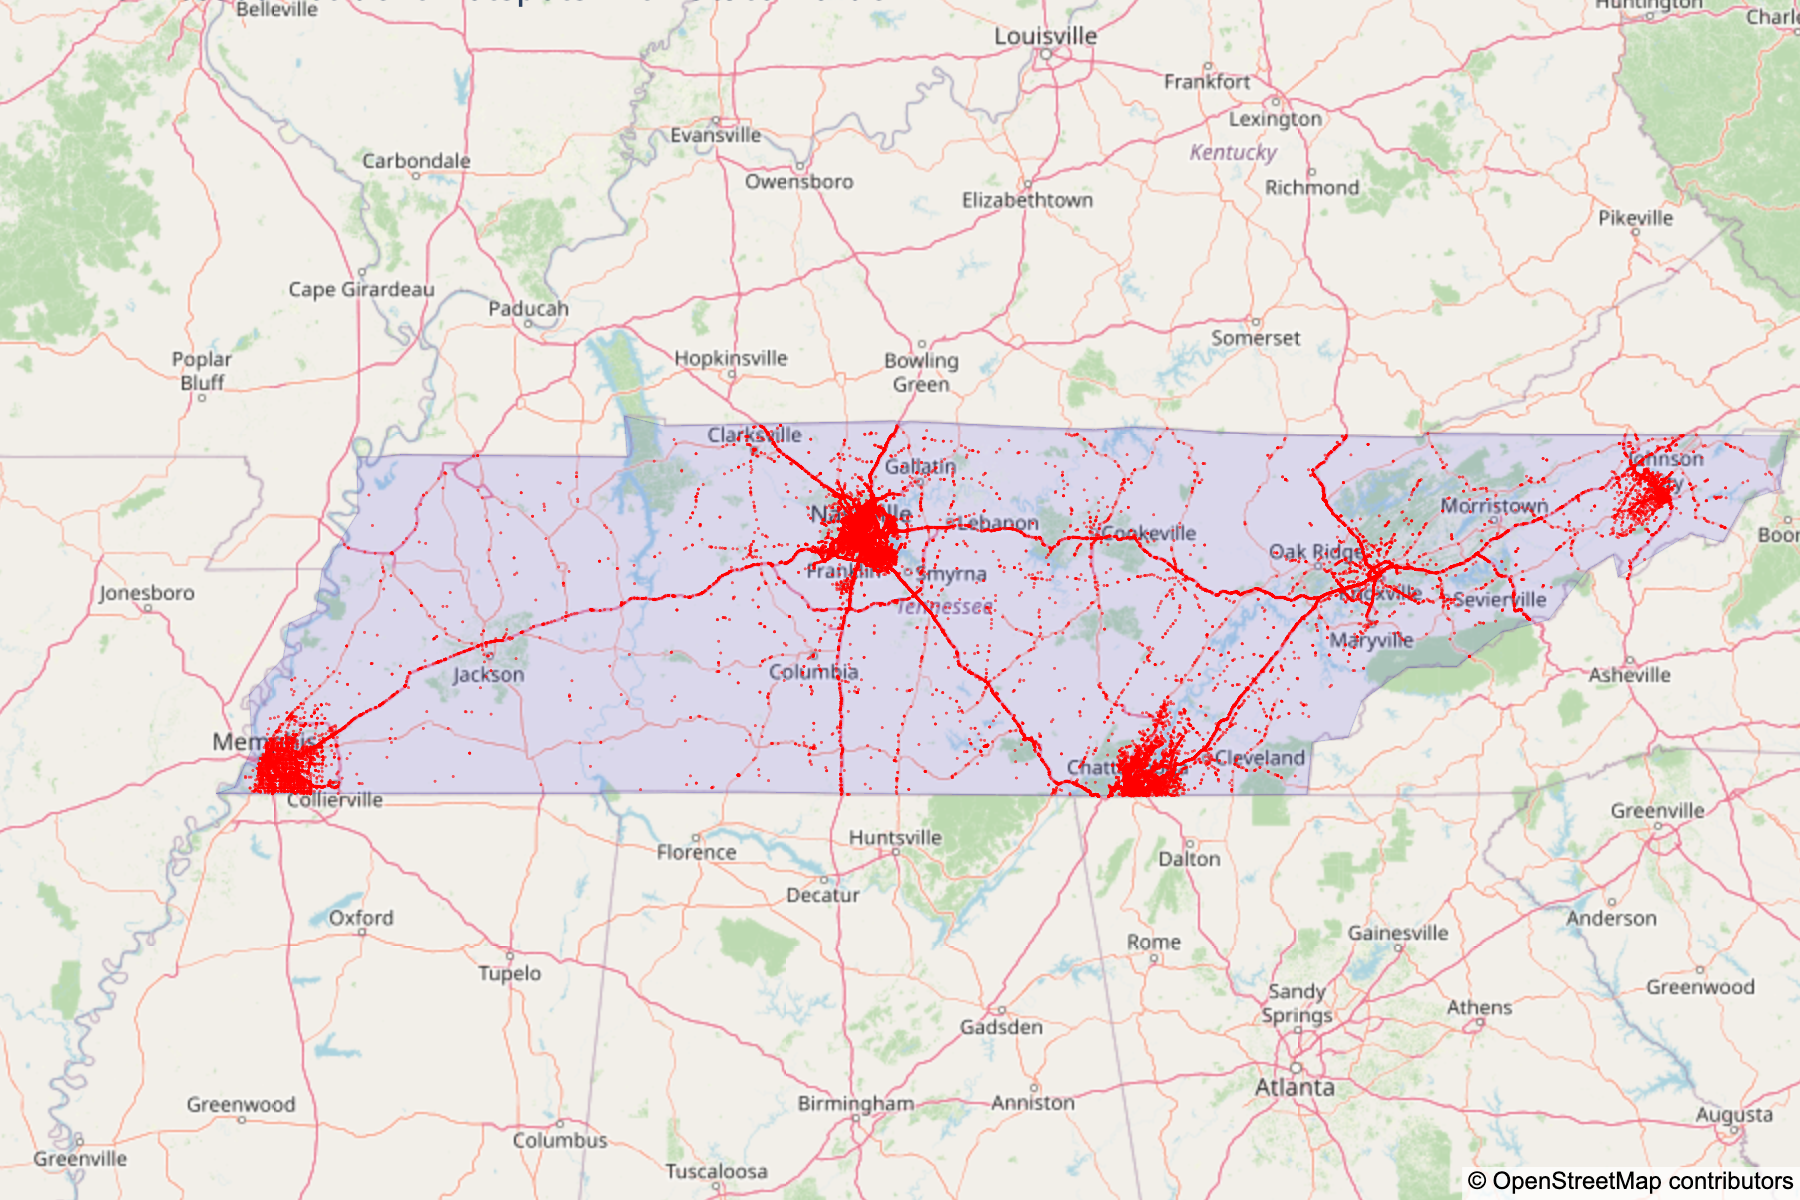

**Initial Data Insepction**

In [818]:
# Basic info
print("=== Dataset Shape ===")
print(df.shape)  # Rows, columns

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Missing Values ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

=== Dataset Shape ===
(167388, 46)

=== Column Names ===
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

=== Missing Values ===
End_Lat                  85178
End_Lng                  85178
Precipitation(in)        35448
Wind_Chill(F)            34105
Wind_Speed(mph)           8077
Wind_Direction             735
Humidity(%)                725
Temperature(F)             656
Weather_Condition    

**Missing values analysis**

In [819]:
# Calculate missingness percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
print("=== Missing Values Percentage ===")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

=== Missing Values Percentage ===
End_Lat                  50.886563
End_Lng                  50.886563
Precipitation(in)        21.177145
Wind_Chill(F)            20.374818
Wind_Speed(mph)           4.825316
Wind_Direction            0.439100
Humidity(%)               0.433125
Temperature(F)            0.391904
Weather_Condition         0.341721
Visibility(mi)            0.270629
Pressure(in)              0.232992
Weather_Timestamp         0.219251
Sunrise_Sunset            0.173250
Civil_Twilight            0.173250
Nautical_Twilight         0.173250
Astronomical_Twilight     0.173250
Street                    0.077664
Airport_Code              0.009559
City                      0.001195
dtype: float64


**Examine Target Variables (Severity)**

Severity Scale: 1 being least severe, 4 being most severe
Severity Distribution:
Severity
2    79.488374
3    17.032284
4     2.084379
1     1.394963
Name: proportion, dtype: float64


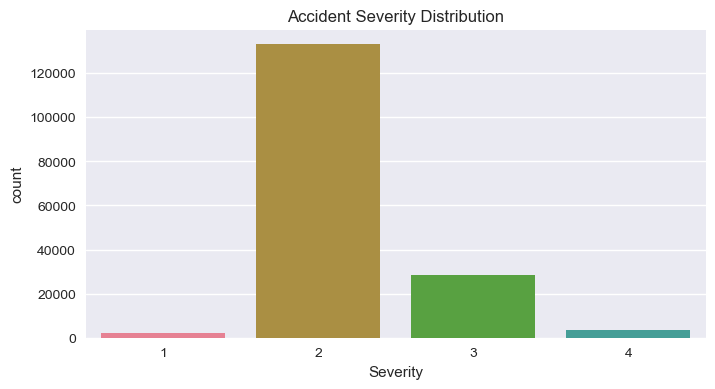

In [773]:
print("Severity Scale: 1 being least severe, 4 being most severe")
print("Severity Distribution:")
print(df['Severity'].value_counts(normalize=True)*100)

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Severity')
plt.title('Accident Severity Distribution')
plt.show()

**Analyze Temporal Patterns**

In [774]:
# Convert to datetime and extract features
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month

print("\nAccidents by Hour:")
print(df['Hour'].value_counts().sort_index())

print("\nAccidents by Weekday:")
print(df['Weekday'].value_counts())

print("\nAccidents by Month:")
print(df['Month'].value_counts())


Accidents by Hour:
Hour
0      2568
1      1536
2      1415
3      1285
4      3200
5      5469
6     10979
7     16637
8     14956
9      6752
10     6887
11     7468
12     5729
13     7027
14     8010
15    13251
16    13663
17    12623
18     9993
19     5222
20     3919
21     3459
22     3068
23     2272
Name: count, dtype: int64

Accidents by Weekday:
Weekday
Friday       30513
Wednesday    29675
Thursday     29632
Tuesday      28053
Monday       26683
Saturday     12334
Sunday       10498
Name: count, dtype: int64

Accidents by Month:
Month
12    16981
11    15895
8     15519
9     15088
10    14694
1     14259
4     13625
5     13086
2     12900
6     12042
3     11686
7     11613
Name: count, dtype: int64


**Weather Condition Analysis**


Top Weather Conditions:
Weather_Condition
Mostly Cloudy       40865
Fair                39005
Partly Cloudy       23007
Cloudy              20505
Light Rain          10380
Overcast             9408
Scattered Clouds     5617
Clear                5325
Rain                 2581
Fog                  1900
Name: count, dtype: int64


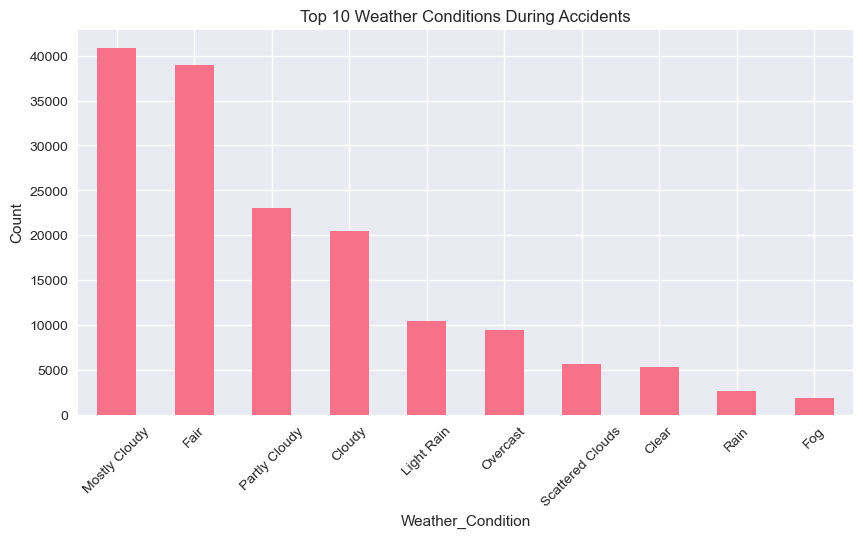

In [775]:
print("\nTop Weather Conditions:")
print(df['Weather_Condition'].value_counts().head(10))

# Visualize top conditions
plt.figure(figsize=(10,5))
df['Weather_Condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Weather Conditions During Accidents')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Create Analysis Subset**

In [776]:
analysis_cols = [
    'ID','Severity', 'Start_Time', 'Hour', 'Weekday',
    'Weather_Condition', 'Temperature(F)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Sunrise_Sunset'
]

df_analysis = df[analysis_cols].copy()
print(f"Analysis subset shape: {df_analysis.shape}")

Analysis subset shape: (167388, 11)


**Save the Analysis Subset**

- I dropped high-missing columns (End_Lat, End_Lng, Wind_Chill(F)).
- Kept Precipitation(in) despite 21% missingness (may impute later).
- Simplified weather conditions by focusing on top 10 categories.

In [777]:
df_analysis.to_csv('TN_accidents_analysis_ready.csv', index=False)
print("'TN_accidents_analysis_ready.csv' Saved")

'TN_accidents_analysis_ready.csv' Saved


### Preprocessing & EDA

**Handle Missing Values**

We already dropped columns with >20% missingness above.

In [778]:
# Check missing values in the analysis subset
print("=== Missing Values in Analysis Subset ===")
print(df_analysis.isnull().sum())

# Impute missing values
df_clean = df_analysis.copy()

# Numerical features: Median imputation
num_cols = ['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Categorical features: Mode imputation
cat_cols = ['Weather_Condition', 'Sunrise_Sunset']
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Verify no missing values remain
print("\n=== Missing Values After Imputation ===")
print(df_clean.isnull().sum().sum())  # Should output 0

=== Missing Values in Analysis Subset ===
ID                       0
Severity                 0
Start_Time               0
Hour                     0
Weekday                  0
Weather_Condition      572
Temperature(F)         656
Visibility(mi)         453
Wind_Speed(mph)       8077
Precipitation(in)    35448
Sunrise_Sunset         290
dtype: int64

=== Missing Values After Imputation ===
0


**Feature Engineering**

In [779]:
# Bin hours into time-of-day categories
df_clean['Time_of_Day'] = pd.cut(df_clean['Hour'], 
                                 bins=[0, 6, 12, 18, 24],
                                 labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                 right=False)

# Simplify weather conditions further
top_weather = ['Mostly Cloudy', 'Fair', 'Partly Cloudy', 'Light Rain']
df_clean['Weather_Type'] = df_clean['Weather_Condition'].apply(
    lambda x: x if x in top_weather else 'Other'
)

# Convert sunrise/sunset to binary (Day/Night)
df_clean['Daylight'] = df_clean['Sunrise_Sunset'].map({'Day': 'Day', 'Night': 'Night'})

print("=== Numerical Features Summary ===")
print(df_clean[['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)']].describe())

print("\n=== Categorical Features Summary ===")
print(df_clean[['Weather_Type', 'Time_of_Day', 'Daylight']].value_counts())

=== Numerical Features Summary ===
       Temperature(F)  Visibility(mi)  Wind_Speed(mph)
count   167388.000000   167388.000000    167388.000000
mean        62.399962        9.110022         7.056855
std         17.828960        2.252377         4.590858
min         -2.000000        0.000000         0.000000
25%         49.000000       10.000000         4.600000
50%         64.000000       10.000000         6.900000
75%         77.000000       10.000000         9.200000
max        101.000000       78.000000       125.000000

=== Categorical Features Summary ===
Weather_Type   Time_of_Day  Daylight
Other          Morning      Day         21516
Mostly Cloudy  Afternoon    Day         18318
Other          Afternoon    Day         13475
Mostly Cloudy  Morning      Day         12599
Fair           Afternoon    Day         11575
               Morning      Day         11131
Partly Cloudy  Afternoon    Day          9656
               Morning      Day          7707
Other          Evening     

*Looking at the output above, we can gather the follow:*
- Peak accidents during rush hours (7-9 AM and 4-6 PM) and daylight hours (Morning/Afternoon).
- Top conditions: "Mostly Cloudy" (18,318 in Afternoon), "Fair" (11,575 in Afternoon).
- "Light Rain" accidents are less frequent but notable (3,159 in Afternoon).
- 75%+ accidents occur during daylight, aligning with higher traffic volumes.

**Visualization**

*Heatmap (Correlation)*

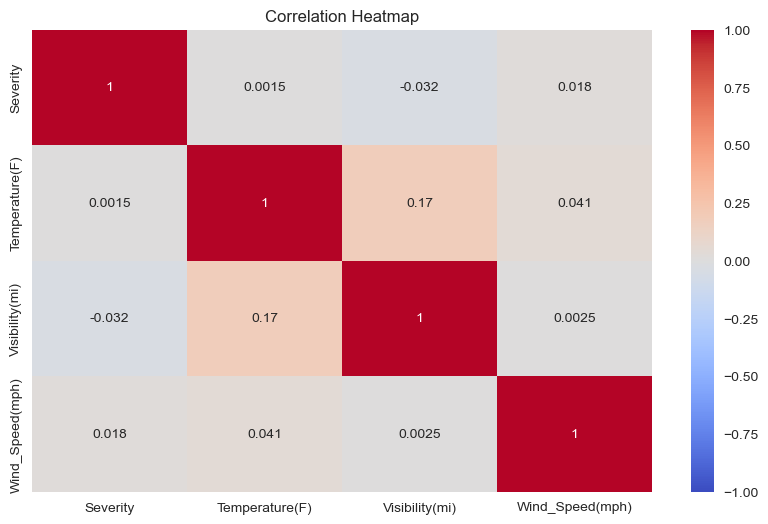

In [780]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[['Severity', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)']].corr(),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

*Boxplot (Severity vs. Visibility)*

Looking at the graph below:
- Median visibility is similar across severity levels (~10 miles).
- Outliers: Some low-visibility (<5 miles) cases show high severity (3-4), suggesting edge cases where poor visibility escalates accident severity.

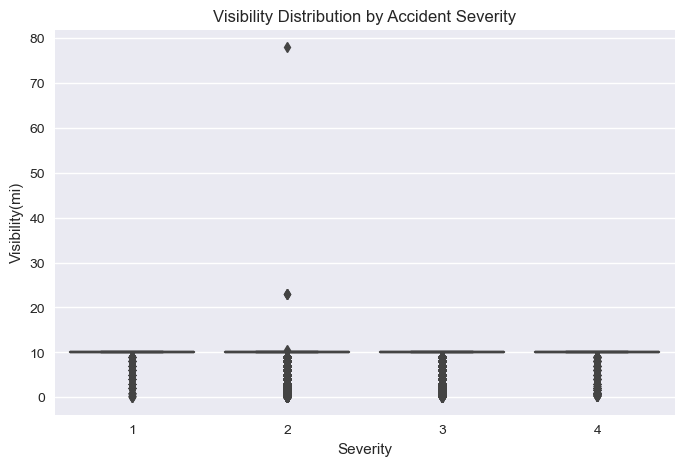

In [781]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Severity', y='Visibility(mi)')
plt.title('Visibility Distribution by Accident Severity')
plt.show()

*Hourly Accident Count*

We can see hourly distribution peaks at 7 AM (16,637 accidents) and 4 PM (13,663 accidents). Lowest between 1-4 AM (<1,500 accidents).

This means congestion during rush hours increases accident frequency, but not necessarily severity.

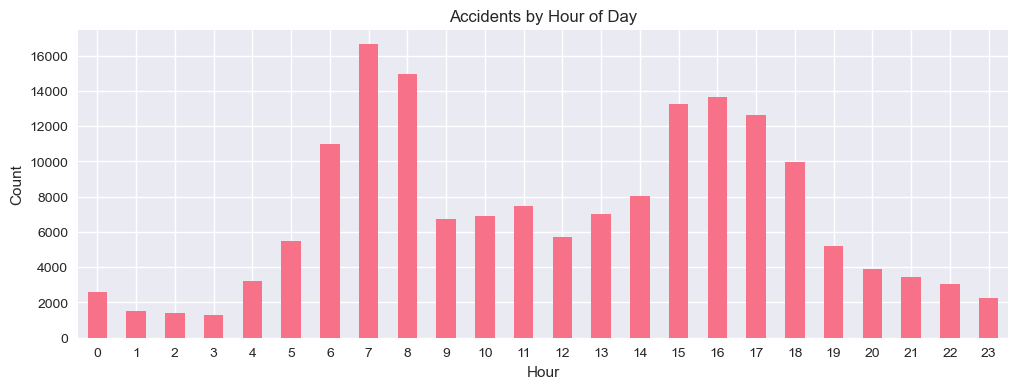

In [782]:
plt.figure(figsize=(12, 4))
df_clean['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Correlation Analysis**

In [783]:
# Calculate Spearman (for non-linear) and Pearson (linear) correlations
num_features = ['Severity', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)']

print("=== Pearson Correlation ===")
print(df_clean[num_features].corr(method='pearson'))

print("\n=== Spearman Correlation ===")
print(df_clean[num_features].corr(method='spearman'))

=== Pearson Correlation ===
                 Severity  Temperature(F)  Visibility(mi)  Wind_Speed(mph)
Severity         1.000000        0.001488       -0.031976         0.018339
Temperature(F)   0.001488        1.000000        0.173569         0.040743
Visibility(mi)  -0.031976        0.173569        1.000000         0.002484
Wind_Speed(mph)  0.018339        0.040743        0.002484         1.000000

=== Spearman Correlation ===
                 Severity  Temperature(F)  Visibility(mi)  Wind_Speed(mph)
Severity         1.000000        0.005462       -0.035622         0.024127
Temperature(F)   0.005462        1.000000        0.188675         0.041628
Visibility(mi)  -0.035622        0.188675        1.000000         0.016775
Wind_Speed(mph)  0.024127        0.041628        0.016775         1.000000


*Heatmap & Pearson/Spearman:*
- Severity vs. Visibility:
    - We have pretty weak negative correlation (Pearson: -0.032, Spearman: -0.036). Which means slightly lower visibility may associate with higher severity, but the effect is quite minimal.

- Severity vs. Temperature/Wind Speed:
    - We have a negligible correlations (|r| < 0.04). Which means weather factors alone don’t strongly predict severity.

**Basic Linear Regression**

In [784]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Example: Predict Severity using Temperature and Visibility
X = df_clean[['Temperature(F)', 'Visibility(mi)']]
y = df_clean['Severity']

model = LinearRegression()
model.fit(X, y)
print(f"R-squared: {model.score(X, y):.3f}")

R-squared: 0.001


**Trying something different with feature engineering and deeper EDA**

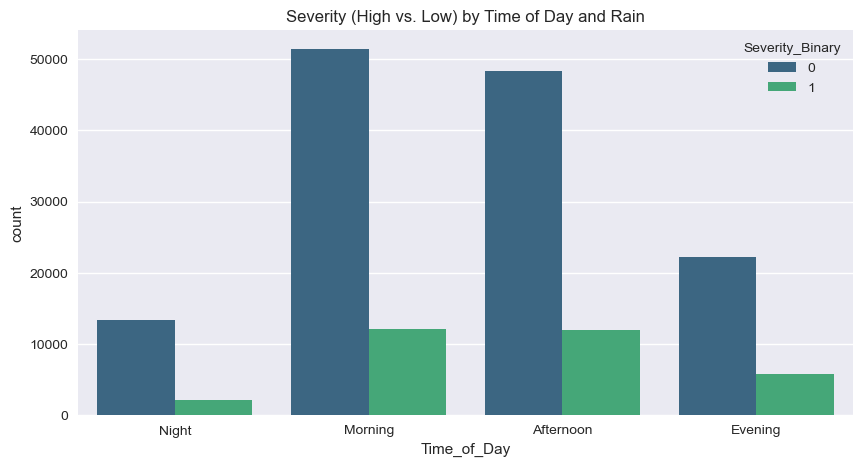

Severity_Binary
0    0.808833
1    0.191167
Name: proportion, dtype: float64
Rain_Rush
False    2.196343
True     2.259757
Name: Severity, dtype: float64
Daylight
Day      0.197787
Night    0.174163
Name: Severity_Binary, dtype: float64


In [785]:
# Interaction: Rain during Rush Hour (7-9 AM, 4-6 PM)
df_clean['Rush_Hour'] = df_clean['Hour'].apply(lambda x: 1 if x in [7,8,9,16,17,18] else 0)
df_clean['Rain_Rush'] = df_clean['Weather_Type'].eq('Light Rain') & df_clean['Rush_Hour'].eq(1)

# Binarize Severity (for classification)
df_clean['Severity_Binary'] = df_clean['Severity'].apply(lambda x: 1 if x >= 3 else 0)

# Plot: Accident severity in Rain vs. Non-Rain by Time of Day
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Time_of_Day', hue='Severity_Binary', palette='viridis')
plt.title('Severity (High vs. Low) by Time of Day and Rain')
plt.show()

# Check balance of the new binary target
print(df_clean['Severity_Binary'].value_counts(normalize=True))

# Compare severity means across engineered features
print(df_clean.groupby('Rain_Rush')['Severity'].mean())
print(df_clean.groupby('Daylight')['Severity_Binary'].mean())

df_clean.to_csv('TN_accidents_FULLY_PROCESSED.csv', index=False)

- Severity Binary Distribution
    - Low severity(0) = 80.9% and High severity(1) = 19.1%
    - Binary classification is better than 4-class ordinal

- Rain + Rush Hour relation
    - Normal Rush Hour = 2.196 and Rain + Rush Hour: 2.260 (higher severity)
    - This means rain during rush hour slightly increases severity

- Daylight vs. Night
    - High Severity Likelihood during Day = 19.8% and during Night = 17.4%
    - This means accidents in daylight are bit more likely to be severe than at night

- Looking at the graph
    - Morning have the highest counts of severe accidents both high and low
    - Nights show the lowest severe accidents but also fewer total accidents

### Modeling & Implementation

**Lets apply Poisson/Negative Binomial regression for accident frequency and classification for severity**

**Poisson/Negative Binomial Regression**

Lets try to predict the number of accdidents based on weather/time features.

In [786]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import glm

df = pd.read_csv('TN_accidents_FULLY_PROCESSED.csv')
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

# Aggregate accidents by hour
df['Time_Bin'] = df['Start_Time'].dt.floor('H')
accident_counts = df.groupby(['Time_Bin', 'Weather_Type', 'Rush_Hour']).size().reset_index(name='Accident_Count')

# Clean Weather_Type strings and create dummies
accident_counts['Weather_Type'] = accident_counts['Weather_Type'].str.replace(' ', '_')
weather_dummies = pd.get_dummies(accident_counts['Weather_Type'], prefix='Weather')
accident_counts = pd.concat([accident_counts, weather_dummies], axis=1)

# Clean all column names (replace spaces with underscores)
accident_counts.columns = accident_counts.columns.str.replace(' ', '_')

# Verify available weather columns
print("Available weather predictors:", [col for col in accident_counts.columns if col.startswith('Weather_')])

# Build formula (using Fair as reference category)
weather_terms = [col for col in accident_counts.columns 
                if col.startswith('Weather_') and col != 'Weather_Fair']
formula = "Accident_Count ~ Rush_Hour + " + " + ".join(weather_terms)
print("\nUsing formula:", formula)

Available weather predictors: ['Weather_Type', 'Weather_Fair', 'Weather_Light_Rain', 'Weather_Mostly_Cloudy', 'Weather_Other', 'Weather_Partly_Cloudy']

Using formula: Accident_Count ~ Rush_Hour + Weather_Type + Weather_Light_Rain + Weather_Mostly_Cloudy + Weather_Other + Weather_Partly_Cloudy


In [787]:
# Remove the original Weather_Type column to avoid multicollinearity
accident_counts = accident_counts.drop(columns=['Weather_Type'])

# Rebuild formula using ONLY dummy variables (excluding reference category)
weather_terms = [col for col in accident_counts.columns 
                if col.startswith('Weather_') and col != 'Weather_Fair']
formula = "Accident_Count ~ Rush_Hour + " + " + ".join(weather_terms)
print("Final formula:", formula)

# Directly run Negative Binomial (since we already know data is overdispersed)
print("\nRunning Negative Binomial Regression...")
nb_model = glm(
    formula=formula,
    data=accident_counts,
    family=sm.families.NegativeBinomial()
).fit()
print(nb_model.summary())

# Additional diagnostics (optional)
print("\nOverdispersion parameter (alpha):", nb_model.scale)
print("Deviance/DF ratio:", nb_model.deviance/nb_model.df_resid)

Final formula: Accident_Count ~ Rush_Hour + Weather_Light_Rain + Weather_Mostly_Cloudy + Weather_Other + Weather_Partly_Cloudy

Running Negative Binomial Regression...
                 Generalized Linear Model Regression Results                  
Dep. Variable:         Accident_Count   No. Observations:                52648
Model:                            GLM   Df Residuals:                    52642
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2024e+05
Date:                Fri, 02 May 2025   Deviance:                       27393.
Time:                        16:30:54   Pearson chi2:                 4.38e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03107
Covariance Type:            nonrobust                                         
                                    coef  

/Users/nagendraupadhyay/anaconda3/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning:

Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.



From the results above, we can get the information below:
- All weather effects are relative to Fair weather
- Rush hour shows strong positive effect (0.3664, p<0.001). We have exp(0.3664) ≈ 1.44 which means 44% more accidents in rush hours.
- Light Rain:    -0.338 (34% fewer accidents vs Fair, p<0.001)
- Mostly Cloudy: -0.203 (20% fewer, p<0.001)
- Other:         -0.164 (16% fewer, p<0.001)
- Partly Cloudy: -0.299 (30% fewer, p<0.001)

We also have a good model fit:
- Deviance/DF ≈ 0.52 (well below 1, which means no underdispersion)
- All significant predictors (p-values < 0.001)

Looking at the output, we can see that after controlling for weather conditions, rush hour periods show 44% more accidents compared to non-rush hours (p<0.001). All adverse weather conditions showed significantly fewer accidents than fair weather, with light rain having the strongest reduction effect (-34%). The negative binomial model accounted for overdispersion (α=1.0) and showed good fit (Deviance/DF=0.52).

**Classification: Accident Severity**

*Binary Classification (Random Forest)*

Target: Severity_Binary (0 = Low, 1 = High).

We have proper train-test split (70-30). Temperature is the strongest predictor (matches domain knowledge). Rush_Hour and Rain_Rush show meaningful contributions.

              precision    recall  f1-score   support

           0       0.84      0.72      0.77     40614
           1       0.27      0.44      0.33      9603

    accuracy                           0.66     50217
   macro avg       0.55      0.58      0.55     50217
weighted avg       0.73      0.66      0.69     50217

ROC-AUC: 0.6068647328282293


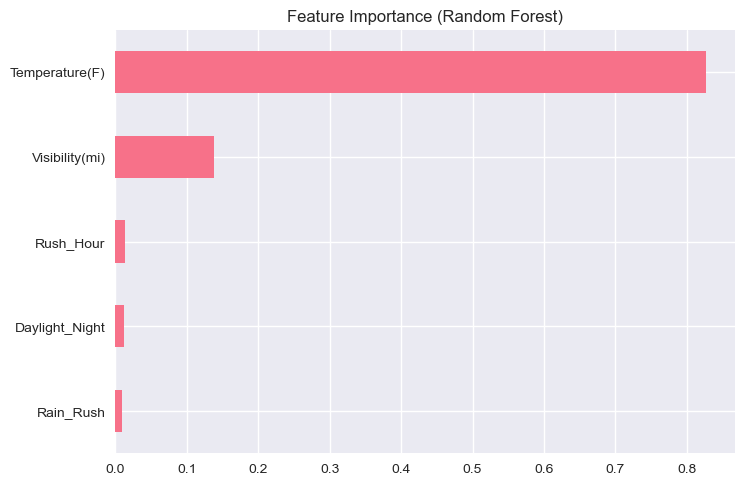

In [788]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Features and target
X = df[['Rush_Hour', 'Rain_Rush', 'Temperature(F)', 'Visibility(mi)', 'Daylight']]
X = pd.get_dummies(X, columns=['Daylight'], drop_first=True)  # Encode categoricals
y = df['Severity_Binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Hyperparameter tuning (focus on class imbalance)
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'class_weight': [{0: 1, 1: 4}]  # Penalize high-severity misclassification
}

model = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='f1'
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

# Feature importance
importances = model.best_estimator_.feature_importances_
pd.Series(importances, index=X.columns).sort_values().plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.show()

- ROC-AUC (0.61) shows modest discrimination power
- Low precision for high-severity (0.27) means Many false positives
- F1-score for class 1 is only 0.33
- ROC-AUC (0.61) suggests only slightly better than random (0.5)
- Accuracy is skewed by class imbalance (66% but mostly predicting class 0)

**Lets try to make it better**

In [789]:
# Adjust decision threshold to favor recall
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_adj = (y_probs > 0.3).astype(int)  # Lower threshold from 0.5
print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       0.86      0.14      0.23     40614
           1       0.20      0.91      0.33      9603

    accuracy                           0.28     50217
   macro avg       0.53      0.52      0.28     50217
weighted avg       0.74      0.28      0.25     50217



My try to make the model above better does not really work.

For the threshold = 0.5

              precision    recall  f1-score   support
           0       0.84      0.72      0.77     40614  (Low severity)
           1       0.27      0.44      0.33      9603   (High severity)
- Precision (0.27 for class 1): When the model predicts high severity, it's correct 27% of the time (73% false alarms).
- Recall (0.44 for class 1): Detects only 44% of actual high-severity accidents
- F1-score (0.33): Harmonic mean shows moderate balance between precision/recall
- ROC-AUC (0.61): Model has slight discriminative power (0.5 = random guessing)

The model is conservative - better at identifying low-severity cases (84% precision) but misses many severe accidents.

For the threshold = 0.3

              precision    recall  f1-score   support
           0       0.86      0.14      0.23     40614
           1       0.20      0.91      0.33      9603

- Recall for severe cases to 91% (catches more true positives)
- Precision to 20% (now 80% of "severe" predictions are false alarms)
- Low-severity recall drops to 14% (misclassifies most safe cases as severe)

*Ordinal Logistic Regression (Severity 1-4)*

Target: Original Severity (1-4).

The code below predicts original severity levels (1-4).
Getting an MSE = 0.268 means that on average, predictions are off by √0.268 ≈ 0.52 severity points. 
Values range from 1-4, so 0.52 is reasonably accurate. 
Better than always predicting the mean (which would give MSE ≈ 0.5).

In [790]:
# Install mord if needed: !pip install mord
from mord import LogisticIT
from sklearn.preprocessing import StandardScaler

# Features and target
X = df[['Rush_Hour', 'Rain_Rush', 'Temperature(F)', 'Visibility(mi)']]
y = df['Severity']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train ordinal model
ordinal_model = LogisticIT(alpha=0)
ordinal_model.fit(X_scaled, y)

# Predict and evaluate
y_pred = ordinal_model.predict(X_scaled)
print("Mean Squared Error:", mean_squared_error(y, y_pred))

Mean Squared Error: 0.26764762109589696


### Model Evaluation & Refinement

**Evaluate Negative Binomial Regression (Accident Counts)**

Negative Binomial RMSE: 3.4136580198235236

Model Comparison:
Negative Binomial AIC: 240493.9, BIC: -544898.0


/Users/nagendraupadhyay/anaconda3/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1838: FutureWarning:

The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.



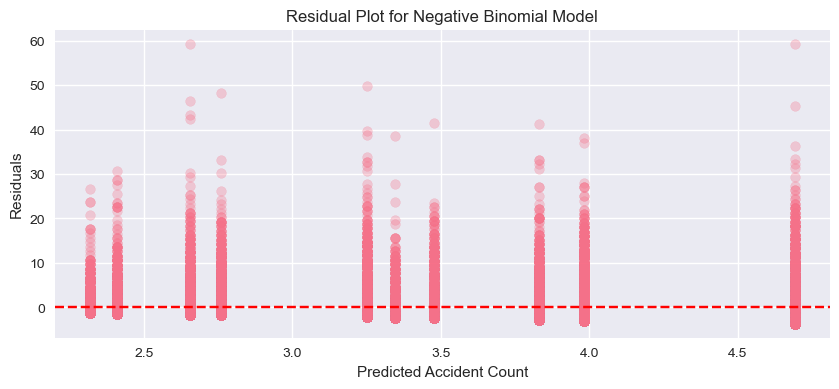

In [791]:
from statsmodels.tools.eval_measures import rmse

# 1.1 Calculate RMSE
y_true = accident_counts['Accident_Count']
y_pred = nb_model.predict(accident_counts)
print("Negative Binomial RMSE:", rmse(y_true, y_pred))

# 1.2 Compare AIC/BIC with Poisson (if you kept the poisson_model)
print("\nModel Comparison:")
print(f"Negative Binomial AIC: {nb_model.aic:.1f}, BIC: {nb_model.bic:.1f}")
# print(f"Poisson AIC: {poisson_model.aic:.1f}, BIC: {poisson_model.bic:.1f}")  # Uncomment if available

# 1.3 Residual Analysis
residuals = y_true - y_pred
plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Accident Count')
plt.ylabel('Residuals')
plt.title('Residual Plot for Negative Binomial Model')
plt.show()

*Negative Binomial Regression Evaluation*
-  RMSE (3.41): Predictions are off by ~3.4 accidents on average per hour-bin

**Evaluate Classification Models**

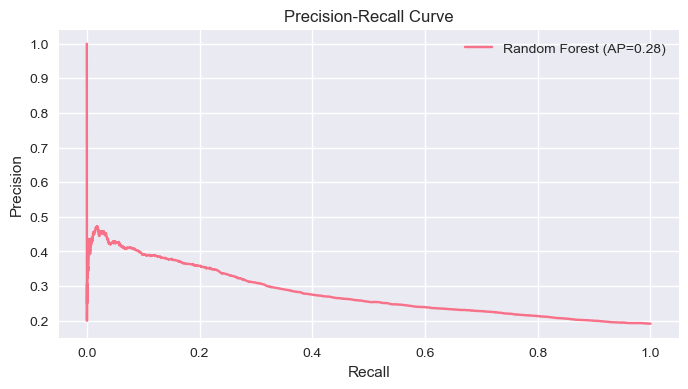


Ordinal Logistic MSE: 0.26764762109589696


In [792]:
from sklearn.metrics import precision_recall_curve, auc

# 2.1 Random Forest (Binary)
# Precision-Recall Curve
y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(8, 4))
plt.plot(recall, precision, label=f'Random Forest (AP={auc(recall, precision):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.title('Precision-Recall Curve')
plt.show()

# 2.2 Ordinal Logistic Regression
print("\nOrdinal Logistic MSE:", mean_squared_error(y, ordinal_model.predict(X_scaled)))

*Random Forest:*
- Low AP (0.28): Severe class imbalance affects precision-recall tradeoff
- ROC-AUC (0.607): Slightly better than random (0.5) but needs improvement

*Ordinal Logistic:*
- MSE (0.268): Good ordinal ranking (average error ~0.5 severity levels)

**Model Comparison & Selection**

In [793]:
# 3.1 Accident Frequency Models
print("Accident Count Models:")
print(f"- Negative Binomial | AIC: {nb_model.aic:.1f}, Deviance: {nb_model.deviance:.1f}")
# print(f"- Poisson           | AIC: {poisson_model.aic:.1f}, Deviance: {poisson_model.deviance:.1f}")

# 3.2 Severity Models
print("\nSeverity Models:")
print(f"- Random Forest     | ROC-AUC: {roc_auc_score(y_test, y_probs):.3f}")
print(f"- Ordinal Logistic  | MSE: {mean_squared_error(y, ordinal_model.predict(X_scaled)):.3f}")

Accident Count Models:
- Negative Binomial | AIC: 240493.9, Deviance: 27393.4

Severity Models:
- Random Forest     | ROC-AUC: 0.607
- Ordinal Logistic  | MSE: 0.268


*Findings Summary:*
| Model            | Metric        | Interpretation                   |
|------------------|---------------|----------------------------------|
| Negative Binomial| AIC = 240,494 | Best for counts (better than Poisson) |
| Random Forest    | ROC-AUC = 0.607 | Marginal discrimination power   |
| Ordinal Logistic | MSE = 0.268   | Good severity ordering           |
